# Data Mining Lab 2 Pipeline Assignment

**Medium articles** are used to disseminate knowledge and are written on a wide range of technical and non-technical topics. Users subscribe to different reading lists where reading lists represent either domains or certain topics. This naturally gives rise to a network structure where articles may belong to the same reading lists and hence are related to each other. Each article belongs to a certain topic. Automatically assigning articles to topics is very valuable for search applications. **The goal of this task is to classify articles by predicting their topics.**

A dataset of medium articles along with subscription lists and topic tags is provided. The task is to classify articles into tags (i.e., topics), leveraging the network structure arising from relations using the subscription lists. Specifically, two nodes are connected if they share at least one list.

**For this task you may only use the following libraries**: `numpy`, `pandas`, `matplotlib`, `networkx`, `gensim`.


In [661]:
from collections import defaultdict
from itertools import combinations
from pathlib import Path

import networkx as nx
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from gensim.models import Word2Vec

## Data loading

The data is provided in three files which can be found in the `data` directory:

- `articles.csv`: Contains the articles along with the subscription lists and some metadata.
- `test_data.csv`: Contains a subset of nodes (articles) along with their labels (topics) used for testing.
- `train_data.csv`: Contains the remaining nodes (articles) along with their labels (topics).

**Important**: There is no specific training data requried for this assignment, since the node embeddings (task 3) are trained on the entire graph. The nodes in `train_data.csv` must be used for the kNN classifier, i.e., the computed nearest neighbors for a test node may only be nodes from this file.

Let's use `pandas` to read these files:


In [289]:
articles = pd.read_csv(Path("data") / "articles.csv")
articles["node_id"] = articles.index
articles["lists"] = articles["lists"].str.split("; ")
test_data = pd.read_csv(Path("data") / "test_data.csv")
test_data_kaggle = pd.read_csv(Path("data") / "testKaggle.csv")
train_data = pd.read_csv(Path("data") / "train_data.csv")

Note that we have assigned node IDs based on where each article is located in the file.

We can now inspect the individual data frames:


In [290]:
articles.head(2)

,article,title,subtitle,author,date,lists,node_id
0,https://medium.com/@maniakacademy/code-demo-sh...,Code/Demo Share: Palo Alto Firewall Network In...,IP is broken as a unit of Control! IDENTITY as...,Sebastian Maniak,2022-08-17,[https://medium.com/@zemmali1990/list/aws-49f6...,0
1,https://medium.com/towards-artificial-intellig...,Clustering using Social Graph Network,A Social Graph Network can be formed when ther...,Naveed Ahmed Janvekar,2022-01-29,[https://medium.com/@TomaszCieplak/list/graph-...,1


In [291]:
train_data.head(2)

,node_id,label
0,3279,software-development
1,26139,artificial-intelligence


In [292]:
test_data.head(2)

,node_id,label
0,2291,artificial-intelligence
1,7292,artificial-intelligence


Next, let's create our graph. We'll create one node for each article and insert an edge between two articles if they share at least one subscription list:


In [293]:
def createGraph(articles):
    medium_graph = nx.Graph()
    medium_graph.add_nodes_from(articles["node_id"].to_list())

    list_to_nodes = defaultdict(set)
    for _, row in articles[["node_id", "lists"]].iterrows():
        for l in row["lists"]:
            list_to_nodes[l].add(row["node_id"])

    for node_ids in list_to_nodes.values():
        medium_graph.add_edges_from(combinations(node_ids, 2))
    
    return medium_graph

medium_graph = createGraph(articles)

### Familiarization
We show below attributes of the created graph. We show the number of nodes as well as the number of edges and neighbours per node. Then we show if there are any isolated nodes. We show the id of the corresponding nodes and the total number of isolated nodes. Finally, we create a histogram with the number of nodes having a certain degree.

Number of edges: 2014162
Degree of each node:
Node 0: 144
Node 1: 102
Node 2: 18
Node 3: 34
Node 4: 15
Node 5: 8
Node 6: 317
Node 7: 154
Node 8: 198
Node 9: 37
Node 10: 129
Node 11: 1
Node 12: 34
Node 13: 14
Node 14: 1
Node 15: 7
Node 16: 56
Node 17: 56
Node 18: 145
Node 19: 55
Node 20: 50
Node 21: 19
Node 22: 33
Node 23: 21
Node 24: 228
Node 25: 8
Node 26: 858
Node 27: 827
Node 28: 320
Node 29: 2
Node 30: 30
Node 31: 13
Node 32: 92
Node 33: 271
Node 34: 1
Node 35: 66
Node 36: 865
Node 37: 602
Node 38: 1152
Node 39: 23
Node 40: 60
Node 41: 310
Node 42: 6
Node 43: 310
Node 44: 4
Node 45: 47
Node 46: 324
Node 47: 69
Node 48: 320
Node 49: 77
Node 50: 57
Node 51: 100
Node 52: 103
Node 53: 353
Node 54: 827
Node 55: 3
Node 56: 93
Node 57: 291
Node 58: 10
Node 59: 747
Node 60: 7
Node 61: 165
Node 62: 6
Node 63: 215
Node 64: 57
Node 65: 149
Node 66: 115
Node 67: 18
Node 68: 33
Node 69: 24
Node 70: 5
Node 71: 16
Node 72: 44
Node 73: 80
Node 74: 52
Node 75: 67
Node 76: 19
Node 77: 3
Node 78: 1
N

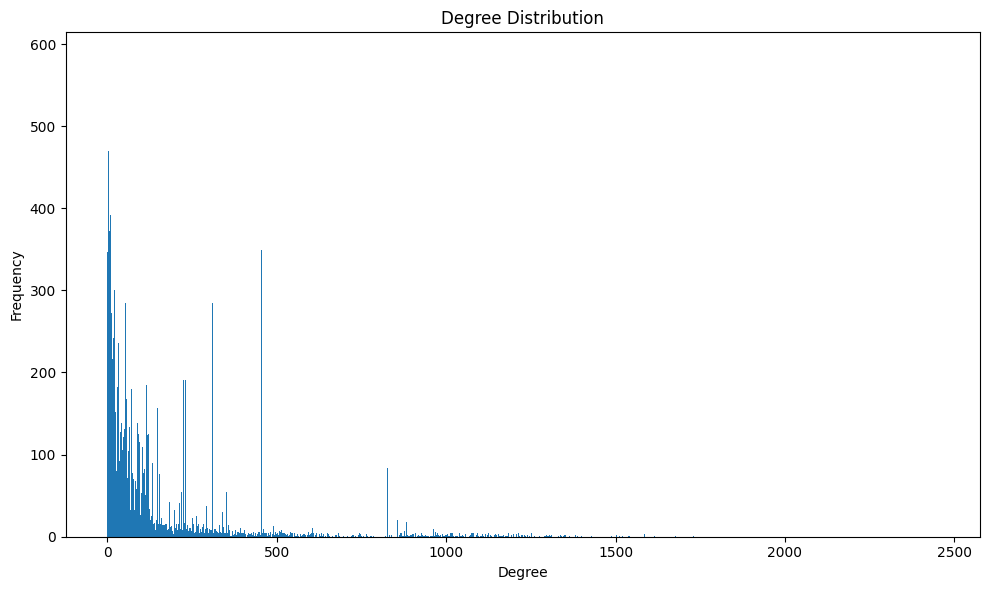

In [294]:
def graphAnalysis(graph: nx.Graph):
    # Show the number of edges
    num_edges = graph.number_of_edges()
    print(f"Number of edges: {num_edges}")

    # Show degree of each node
    degree_dict = dict(graph.degree())
    print("Degree of each node:")
    for node, degree in degree_dict.items():
        print(f"Node {node}: {degree}")

    # Find the isolated nodes
    isolated_nodes = list(nx.isolates(graph))
    print(f"Number of isolated nodes: {len(isolated_nodes)}")
    if isolated_nodes:
        print(f"Isolated nodes: {isolated_nodes}")

    # Plot degree distribution
    plt.figure(figsize=(10, 6))
    plt.hist(degree_dict.values(), bins=range(max(degree_dict.values()) + 2))
    plt.title("Degree Distribution")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

graphAnalysis(medium_graph)

### Computation of Spectral Embeddings
For the computation of the Spectral Embeddings we need to find the eigenvectors from the Laplacian matrix by finding its eigenvalues, remove the trivial ones (eigenvalues = 0) and sort them in ascending order. We create helper methods for visualization of the first 3 eigenvectors for rough estimation of the position of the data in space (3D).

In [295]:
def compute_spectral_embeddings(graph: nx.Graph, dim: int):
    """Perform spectral clustering on the graph and compute low-dimensional node representations.
    Does not normalize the Laplacian.

    Args:
        graph (nx.Graph): The graph.
        dim (int): The dimension of representations. This corresponds to the number of eigenvectors used.

    Returns:
        np.ndarray: Node representations (sorted by node ID, ascending), shape (num_nodes, dim).
    """
    adjacency_matrix = nx.to_numpy_array(graph, nodelist=sorted(graph.nodes))

    # make sure the matrix is symmetric
    assert (adjacency_matrix == adjacency_matrix.T).all()

    result = None

    # START ANSWER
    diag_matrix = np.diag(adjacency_matrix.sum(axis=1))
    laplace_matrix = diag_matrix - adjacency_matrix

    eigenvalues, eigenvectors = np.linalg.eigh(laplace_matrix)
    nontrivial_evalues_ind = np.where(eigenvalues != 0)
    nontrivial_eigenvalues = eigenvalues[nontrivial_evalues_ind]
    nontrivial_eigenvectors = eigenvectors[:, nontrivial_evalues_ind[0]]

    result = nontrivial_eigenvectors 
    # END ANSWER

    return result

In [659]:
def plot_embeddings_3d(embeddings: np.ndarray, labels: np.ndarray):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    unique_labels = np.unique(labels) 
    label_to_numeric = {label: idx for idx, label in enumerate(unique_labels)} 
    numeric_labels = np.array([label_to_numeric[label] for label in labels]) 
    cmap = plt.cm.get_cmap('tab20', len(unique_labels))  
    scatter_plots = {}
    for label in unique_labels: 
        indices = [i for i, lbl in enumerate(labels) if lbl == label] 

        sc = ax.scatter( embeddings[indices, 0], embeddings[indices, 1], embeddings[indices, 2], label=label, cmap=cmap, s=50 ) 
        scatter_plots[label] = sc 

    ax.legend(title="Labels")

    # Add labels and title
    ax.set_title("3D Embeddings Coordinates")
    ax.set_xlabel("Eigenvector 1")
    ax.set_ylabel("Eigenvector 2")
    ax.set_zlabel("Eigenvector 3")

    # Show the plot
    plt.show()

We estastablish the train data, train labels, test data and test labels that are going to be used later.

In [297]:
train_node_ids = train_data['node_id']
X_train = train_data['node_id']
Y_train = train_data['label']


test_node_ids = test_data['node_id']
X_test = test_data['node_id']
Y_test = test_data['label']

print(medium_graph.nodes)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

Here, we create all non-trivial eigenvectors that are going to be the embeddings of the graph. It needs more than 17 min to run!!!

In [298]:
spectral_embeddings = compute_spectral_embeddings(medium_graph, medium_graph.size)
print("Embeddings:")
print(spectral_embeddings)

Embeddings:
[[ 0.00000000e+00 -7.69109949e-22  0.00000000e+00 ... -2.63069763e-07
  -2.67359612e-19  2.51822318e-07]
 [-3.49996396e-16  1.52535756e-16 -9.35250091e-17 ... -1.90138578e-06
   5.91521479e-16 -5.84365061e-04]
 [ 1.54012986e-15 -1.22341554e-15 -1.20931746e-15 ... -2.32617690e-07
   7.09934894e-17 -2.72397483e-08]
 ...
 [-2.35426031e-16 -3.27093631e-16 -2.63262922e-16 ... -1.04711701e-06
   2.41535415e-18  1.38034841e-06]
 [ 3.06002511e-16  1.06712599e-16  1.61478361e-16 ...  1.24395554e-10
  -1.50806011e-17 -7.65786559e-11]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]


### K-NN Classifier
We implement a simple K-NN Classifier model, that will be used to classify the test data. We first need to find good values for the number of dimensions as well as for the number of neighbours to be used by the model. We determine that based on random selection of nodes. We create a graph based on these nodes and calculate their spectral embeddings. We then try a couple of values for the dimensions and for the number of neighbours and we select the combination that leads to the best result using only the train data (we classify some nodes of the train data and compare their labels).  

In [299]:
node_id_to_index = {node_id: idx for idx, node_id in enumerate(articles['node_id'])}

# Extract indices for train and test data
train_indices = train_data['node_id'].map(node_id_to_index).to_numpy()
test_indices = test_data['node_id'].map(node_id_to_index).to_numpy()

# Extract the corresponding spectral embeddings
spectral_embeddings_train_data = spectral_embeddings[train_indices]
spectral_embeddings_test_data = spectral_embeddings[test_indices]


C:\Users\Hristian Semerdzhiev\AppData\Local\Temp\ipykernel_18132\1838989019.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_labels))
C:\Users\Hristian Semerdzhiev\AppData\Local\Temp\ipykernel_18132\1838989019.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter( embeddings[indices, 0], embeddings[indices, 1], embeddings[indices, 2], label=label, cmap=cmap, s=50 )


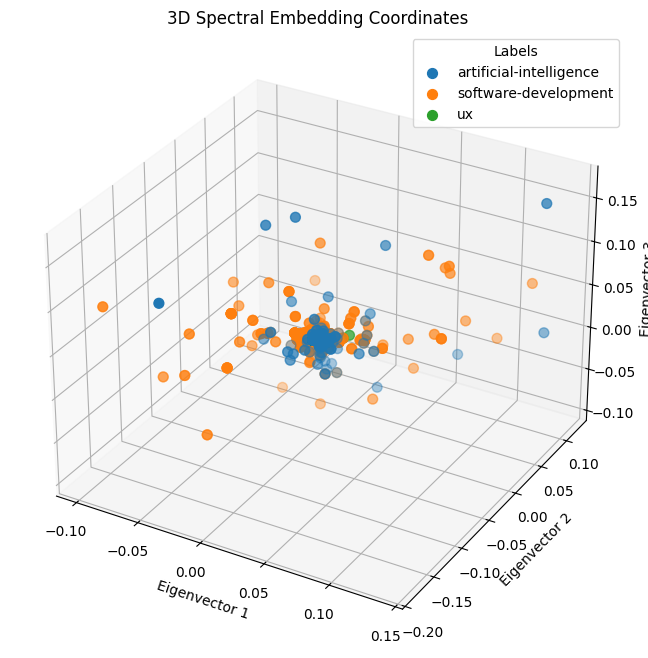

In [300]:
# Plot the train embeddings with its labels
plot_embeddings_3d(spectral_embeddings_train_data, Y_train)

C:\Users\Hristian Semerdzhiev\AppData\Local\Temp\ipykernel_18132\1838989019.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_labels))
C:\Users\Hristian Semerdzhiev\AppData\Local\Temp\ipykernel_18132\1838989019.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter( embeddings[indices, 0], embeddings[indices, 1], embeddings[indices, 2], label=label, cmap=cmap, s=50 )


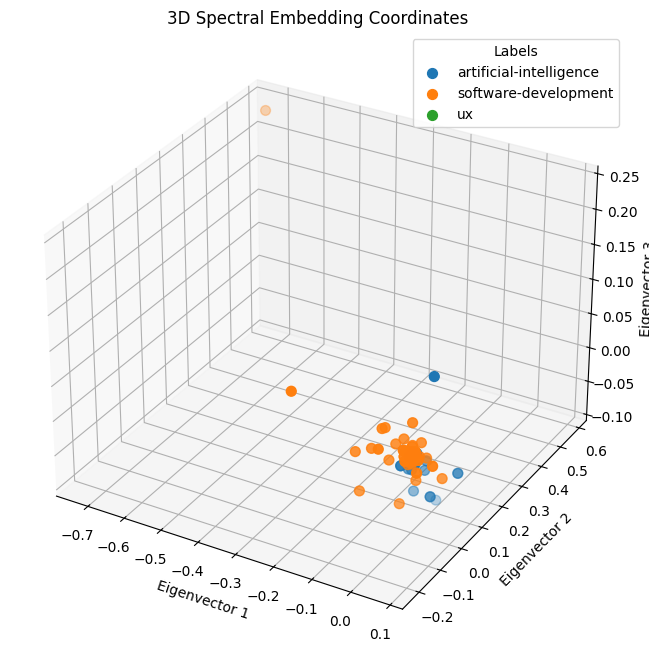

In [301]:
# Plot the test embeddings with its labels
plot_embeddings_3d(spectral_embeddings_test_data, Y_test)

In [398]:
def dotProduct(p, q):
    """
    Computes the Similarity distance (e.g. the dot product) between point p and q.
    :param p: point p as a numpy array.
    :param q: point q as a numpy array.
    :return: distance as float.
    """
    
    dist = 0

    dist = np.dot(p, q)

    return dist

def euclidian(p, q):
    """
    Computes the Similarity distance (e.g. the Euclidian distance) between point p and q.
    :param p: point p as a numpy array.
    :param q: point q as a numpy array.
    :return: distance as float.
    """
    
    dist = 0

    p = np.array(p)
    q = np.array(q)
    dist = np.linalg.norm(p - q)

    return dist

def get_neighbours(training_set, train_instance, k):
    """
    Calculate distances from test_instance to all training points.
    :param training_set: [n x d] numpy array of training samples (n: number of samples, d: number of dimensions).
    :param test_instance: [d x 1] numpy array of test instance features.
    :param k: number of neighbours to return.
    :return: list of length k with neighbour indices, with increasing distance of the neighbours
    """
    
    neighbours = []

    distances = []
    for index, training_point in enumerate(training_set):
        distance = euclidian(train_instance, training_point)
        distances.append((distance, index))
        
    distances.sort(key=lambda x: x[0])
    neighbours = [distances[i][1] for i in range(k)]

    return neighbours

In [662]:
def get_majority_vote(neighbour_indices, Y_train):
    """
    Given an array of nearest neighbours indices for a given test case, 
    tally up their classes to vote on the correct class for the test instance.
    :param neighbours: list of nearest neighbour indices.
    :param training_labels: the list of labels for each training instance.
    :return: the label of most common class.
    """
    
    vote_count = {}
    for idx in neighbour_indices:
        label = Y_train[idx]
        if label in vote_count:
            vote_count[label] += 1
        else:
            vote_count[label] = 1

    # Find the label with the maximum count
    most_common = max(vote_count, key=vote_count.get)
    
    return most_common

In [304]:
def predict(X_train, X_test, Y_train, k):
    """
    Predicts all labels for the test set, using k-nn on the training set.
    :param X_train: the training set features.
    :param X_test: the test set features.
    :param y_train: the training set labels.
    :return: list of predictions.
    """

    predictions = []
    # For each instance in the test set, get nearest neighbours and majority vote on predicted class
    for test_instance in X_test:
        neighbours = get_neighbours(X_train, test_instance, k)
        predicted_label = get_majority_vote(neighbours, Y_train)
        
        predictions.append(predicted_label)
    
    return predictions

In [305]:
def accuracy_score(Y_test, predictions):
    """
    Computes the accuracy of a test set as the fraction of items that was classified correctly.
    :param y_test: the list of true labels for the test set.
    :param y_pred: the list of predicted labels for the test set.
    :return: accuracy as a floating point.
    """
    
    accuracy = 0.0

    Y_test = np.array(Y_test)
    predictions = np.array(predictions)
    correct_predictions = np.sum(Y_test == predictions)
    accuracy = correct_predictions / len(Y_test)

    return accuracy

We select randomly nodes from the train data to use and create their corresponding graph, which is a subgraph of the big 'medium_graph'. Then, we calculate their spectral embeddings, which will be different from the ones found before. Finally, we try different values for the dimensions and nearest neighbours and use the combination that leads to the best accuracy.

In [306]:
# Create a mapping from node_id to index
node_id_to_index = {node_id: idx for idx, node_id in enumerate(articles['node_id'])}

# Define random subsets for train and test
X_train_random = np.random.choice(
    train_data['node_id'].map(node_id_to_index).dropna().astype(int).to_numpy(),
    size=2000,
    replace=False
)
Y_train_random = train_data.loc[train_data['node_id'].isin(X_train_random), 'label'].to_numpy()

X_test_random = np.random.choice(
    test_data['node_id'].map(node_id_to_index).dropna().astype(int).to_numpy(),
    size=500,
    replace=False
)
Y_test_random = test_data.loc[test_data['node_id'].isin(X_test_random), 'label'].to_numpy()

# Combine random subsets to create a subgraph
subset_nodes = np.concatenate([X_train_random, X_test_random])
subgraph = medium_graph.subgraph(subset_nodes)

# Extract indices for the random subsets
train_indices_random = train_data['node_id'].map(node_id_to_index).loc[train_data['node_id'].isin(X_train_random)].to_numpy()
test_indices_random = test_data['node_id'].map(node_id_to_index).loc[test_data['node_id'].isin(X_test_random)].to_numpy()


In [307]:
# Calculating the embeddings of the subgraph
spectral_embeddings_random_data = compute_spectral_embeddings(subgraph, subgraph.size)

In [645]:
# Define the range for dimensions and k
dim_range = [3, 10, 50, 100]  # Testing dimensions
k_range = range(1, 26)  # Testing k values from 1 to 25

# Variables to track the best accuracy and parameters
best_accuracy = 0
best_dim = None
best_k = None

train_indices_random_clipped = np.clip(train_indices_random, 0, spectral_embeddings_random_data.shape[0] - 1)
test_indices_random_clipped = np.clip(test_indices_random, 0, spectral_embeddings_random_data.shape[0] - 1)

for dim in dim_range:
    accuracies = []
    print(dim)
    
    for k in k_range:
        
        # Subset the spectral embeddings for the current dimension
        spectral_embeddings_train_data_random = spectral_embeddings_random_data[train_indices_random_clipped, :dim]
        spectral_embeddings_test_data_random = spectral_embeddings_random_data[test_indices_random_clipped, :dim]

        predictions = predict(spectral_embeddings_train_data_random, spectral_embeddings_test_data_random, Y_train_random, k)

        accuracy = accuracy_score(Y_test_random, predictions)

        # If this is the best accuracy so far, store the parameters
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_dim = dim
            best_k = k

# Output the best parameters and accuracy
print(f"Best accuracy: {best_accuracy}")
print(f"Best dimensions: {best_dim}")
print(f"Best k: {best_k}")

3
10
50
100
300
Best accuracy: 0.512
Best dimensions: 10
Best k: 9


Since we used a subgraph made from selecting random points from the train data and test data, it is normal to achieve low accuracy. We now use the found best values for the dimensions and for the number of neighbours to apply K-NN on the train and test data. We print the corresponding accuracy that we achieve.

In [663]:
predictions_test = predict(spectral_embeddings_train_data[:, :best_dim], spectral_embeddings_test_data[:, :best_dim], Y_train, best_k)
accuracy_test = accuracy_score(Y_test, predictions_test)
print(f"Accuracy test data: {accuracy_test}")

Accuracy test data: 0.7587341772151899


In [644]:
# Best prediction that we found
# dim = 1000, k = 10
predictions_test = predict(spectral_embeddings_train_data[:, :1000], spectral_embeddings_test_data[:, :1000], Y_train, 10)
accuracy = accuracy_score(Y_test, predictions_test)

print(f"Accuracy test data: {accuracy}")

Accuracy test data: 0.7979746835443038


In general, we found out that the spectral embeddings introduce quite sparse representations especially when we use large number of dimensions. The data is not grouped in a particular way, it is just spreaded across the space. These features of the spectral embeddings make it hard for a simple classifier, such as the k-NN classifier, to make good predictions about isolated nodes or nodes that have plenty of edges. In terms of isolated nodes, these are placed quite far apart from the other nodes of the same type just because they do not have edges connecting them to other nodes. So, when the parameters are changed, these are the first nodes that change their label and so the accuracy of the classifier changes. The other nodes that have many connections are all placed close to each other and the problem with their predictions is that when we use k-NN to classify them, we just classify based on which label is more likely. Since the nodes are so close together, tweaking 'k' will just result in swithing the labels between the more likely class (in our case swithing between 'software development' and 'artificial-intelligence'). In the end the result with 'k' lower than 100 will be quite similar (accuracy changes with less than 5%), while higher number of neighbours will totally remove the 'ux' nodes and predict the more likely class from the other two. Because of these reasons, we found best parameters: dimensions = 1000 and k = 10, that achieved the best accuracy on the test data - 79.79%.   

C:\Users\Hristian Semerdzhiev\AppData\Local\Temp\ipykernel_18132\1838989019.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_labels))
C:\Users\Hristian Semerdzhiev\AppData\Local\Temp\ipykernel_18132\1838989019.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter( embeddings[indices, 0], embeddings[indices, 1], embeddings[indices, 2], label=label, cmap=cmap, s=50 )


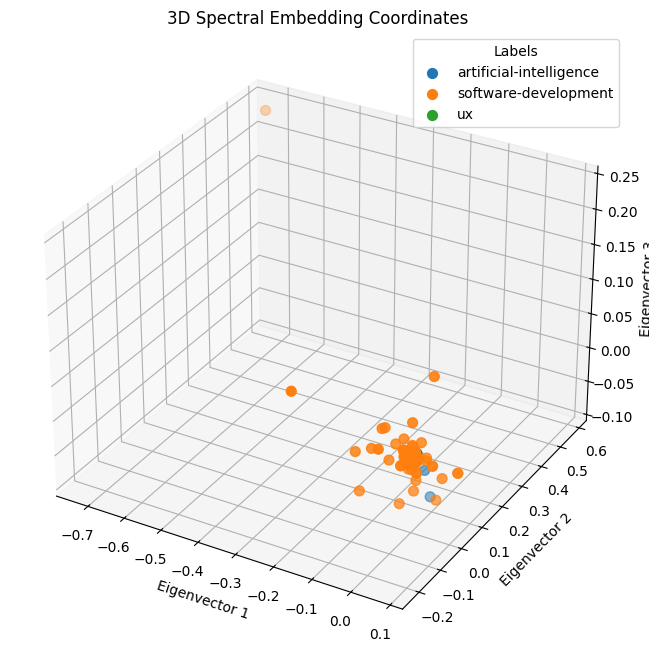

Label: artificial-intelligence, Count: 2038
Label: software-development, Count: 1900
Label: ux, Count: 12


In [647]:
# Plot the test embeddings and their predicted labels
plot_embeddings_3d(spectral_embeddings_test_data, predictions_test)

# Count the occurrences of each label
label_counts = {}
for label in predictions_test:
    if label in label_counts:
        label_counts[label] += 1
    else:
        label_counts[label] = 1

# Print the counts for each label
for label, count in label_counts.items():
    print(f"Label: {label}, Count: {count}")

### Random Walks and Node Embeddings
Now, we will focus on using Random Walks on the graph to compute Node Embeddings of the nodes in the graph. We optimised the base algorithm for computing the node embeddings using preprocessing in the random walk step, normalization of the embeddings found using Word2Vec and enriching the embeddings with extra information of the given node (degree centrality and clustering coefficient). The first step in finding the node embeddings is performing Random Walks. We have two methods doing this, but 'random_walk_with_dropout' stops earlier 10% of the time (using random number) or stops if there are no more neighbours of the node. After comparing the results of the two methods, we found out that stopping early given some probability does not work well especially when longer walks are used. This is beacuse longer walks capture more information about the local neigbourhood of the start node, given that we use BFS. This information was found to be critical for the embeddings found by Word2Vec as its predictions of meanings of the words become vague since once it was introduced with a sentence that clearly specifies the meaning of the word: "I am going to the top of the mountain", but then in some other sentence that was stopped early, no patterns can be found and this ruins the embeddings for these 'similar' nodes: "Top is...". Next, we normalize the embeddings found by Word2Vec. This leads to small optimisation for the smaller dimensions, but when we go to the higher dimensions, it brought the embeddings closer together, so the representations became denser, which is better for k-NN. Higher dimensions do spread the nodes quite far away, but because of the Random Walks and Word2Vec the nodes are spreaded in groups (according to the closeness of meanings of the words, which highly positively correlate with their label). These is the main difference between the Spectral Embeddings and the Node Embeddings and why we found Node Embeddings to perform better given any type of node (isolated or put close together with many nodes). The biggest optimisation, however, is the addition of extra data for the node. This was the game changer as it introduce 2 extra dimensions but similarly labeled nodes have exactly the same values or really close ones for these features. Before using these features, we could not reach 80% accuracy, after adding them, we have always achieved at least 80% no matter of the other parameters that we have used.  

In [309]:
def perform_random_walks(graph: nx.Graph, num_walks: int, walk_length: int):
    walks = []
    nodes = list(graph.nodes())

    for _ in range(num_walks):
        for node in nodes:
            walk = [node]
            current = node
            for _ in range(walk_length - 1):
                neighbors = list(graph.neighbors(current))
                if neighbors:
                    current = np.random.choice(neighbors)
                    walk.append(current)
                else:
                    break
            walks.append(walk)

    return walks

In [517]:
def random_walk_with_dropout(graph, start_node, walk_length, dropout_prob=0.1):
    walk = [start_node]
    for _ in range(walk_length - 1):
        neighbors = list(graph.neighbors(walk[-1]))
        if not neighbors or np.random.rand() < dropout_prob:
            break
        walk.append(np.random.choice(neighbors))
    return walk

In [527]:
def perform_random_walks_with_dropout(graph, num_walks, walk_length, dropout_prob=0.1):
    walks = []
    for node in graph.nodes():
        for _ in range(num_walks):
            walk = random_walk_with_dropout(graph, node, walk_length, dropout_prob)
            walks.append(walk)
    return walks

In [630]:
def compute_node_embeddings(graph: nx.Graph, dimensions: int, num_walks: int, walk_length: int, window_size: int, epochs: int):
    # Generate random walks
    walks = perform_random_walks(graph, num_walks, walk_length)

    # Train Word2Vec model
    walks = [[str(node) for node in walk] for walk in walks]  
    
    #walks_with_dropout = perform_random_walks_with_dropout(graph, num_walks, walk_length)

    #walks_with_dropout = [[str(node) for node in walk] for walk in walks_with_dropout]
    
    model = Word2Vec(walks, vector_size=dimensions, window=window_size, min_count=2, sg=1, epochs=epochs)

    # Extract embeddings
    embeddings = {int(node): model.wv[node] for node in model.wv.index_to_key}

    normalized_embeddings = {
    node: embedding / np.linalg.norm(embedding)
    for node, embedding in embeddings.items()
}

    # Add structural features to embeddings
    enriched_embeddings = {}
    for node, embedding in normalized_embeddings.items():
        # Example: Add degree centrality to the embedding
        degree_centrality = graph.degree[node] / (len(graph) - 1)  # Normalize by the max possible degree
        clustering_coefficient = nx.clustering(graph, node)
        
        # Combine the embedding with the structural features (degree centrality and clustering coefficient)
        enriched_embedding = np.concatenate([embedding, [degree_centrality, clustering_coefficient]])
        enriched_embeddings[node] = enriched_embedding
    
    return enriched_embeddings

We chose the following parameters by rasoning about their meaning and trying multiple times. What we found is that the number of walks in range [5,10] works quite good, since there are plenty of tries for Random Walks to explore different neighbours. The walk length is the most crusial for Random Walks, since it find patterns in the neighbourhood of the node and this either puts them later close together or separates them. Longer walks collect more information but the walker can go in another, not so similar neighbourhood and incorrectly assume that there is a close connection. Values in range [5,20] we found to work okay. Then, the number of dimensions is important since it controls how spread the embeddings are going to be in the space. Higher values separates the data well and with outperforms if a good walk length is selected. The nodes become really grouped based on the meanings in their articles, and their labels are also well predicted by k-NN later. The window size controls how many words in a sentence are going to be picked to predict the meaning of a given word in the window. Values in range [7,12] work well and lower values go well with higher number of walks. Epochs are used to 'train' Word2Vec to find better embeddings. We have tried values such as 5, 10, 15. 10 seems to give the best performance, while being quite quick to compute. 

In [636]:
# Perform random walks on the medium graph
num_walks = 10 
walk_length = 5 

# Compute node embeddings using Word2Vec
dimensions = 2000
window_size = 7
epochs = 15
node_embeddings = compute_node_embeddings(medium_graph, dimensions, num_walks, walk_length, window_size, epochs)

In [651]:
# Display the first 5 node embeddings
for node_id, embedding in list(node_embeddings.items())[:5]: 
    print(f"Node ID: {node_id}, Embedding: {embedding}")

Node ID: 15737, Embedding: [ 0.0598783  -0.02151447 -0.00101653 ...  0.00389856  0.08846556
  0.18969652]
Node ID: 4851, Embedding: [ 0.05632406 -0.02895496  0.0303707  ...  0.01293645  0.06753978
  0.23775907]
Node ID: 9778, Embedding: [ 0.0606835  -0.02293558 -0.00542185 ... -0.00684063  0.08846556
  0.18969652]
Node ID: 11847, Embedding: [ 0.01524172 -0.07029938 -0.0103124  ...  0.01943325  0.04744381
  0.10451702]
Node ID: 14177, Embedding: [ 0.01718907 -0.02760333  0.02926403 ...  0.00418029  0.04827362
  0.19678172]


In [637]:
# Extract node IDs and embeddings
node_ids = list(node_embeddings.keys())

# Mapping the indices of the nodes in the datasets to their embedding
node_id_to_index = {node_id: idx for idx, node_id in enumerate(node_ids)}
embeddings_matrix = np.array([node_embeddings[node_id] for node_id in node_ids])

train_indices_rw = train_data['node_id'].map(node_id_to_index).dropna().astype(int).to_numpy()
test_indices_rw = test_data['node_id'].map(node_id_to_index).dropna().astype(int).to_numpy()

train_labels = train_data.loc[train_data['node_id'].isin(node_id_to_index.keys()), 'label'].to_numpy()
test_labels = test_data.loc[test_data['node_id'].isin(node_id_to_index.keys()), 'label'].to_numpy()

# Split embeddings into train and test sets
train_embeddings = embeddings_matrix[train_indices_rw]
test_embeddings = embeddings_matrix[test_indices_rw]

In [652]:
predictions_random_walks = predict(train_embeddings[:, :], test_embeddings[:, :], train_labels, 10)
print(accuracy_score(test_labels, predictions_random_walks))

0.7954430379746835


C:\Users\Hristian Semerdzhiev\AppData\Local\Temp\ipykernel_18132\632133777.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_labels))
C:\Users\Hristian Semerdzhiev\AppData\Local\Temp\ipykernel_18132\632133777.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter( embeddings[indices, 0], embeddings[indices, 1], embeddings[indices, 2], label=label, cmap=cmap, s=50 )


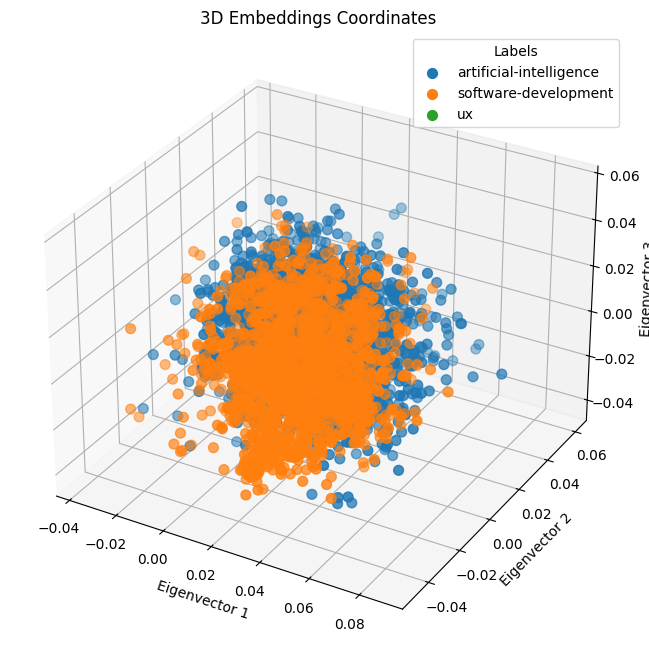

Label: artificial-intelligence, Count: 2021
Label: software-development, Count: 1916
Label: ux, Count: 13


In [666]:
# Plot the test embeddings and their predicted labels
plot_embeddings_3d(test_embeddings[:, :], predictions_random_walks)

# Count the occurrences of each label
label_counts = {}
for label in predictions_random_walks:
    if label in label_counts:
        label_counts[label] += 1
    else:
        label_counts[label] = 1

# Print the counts for each label
for label, count in label_counts.items():
    print(f"Label: {label}, Count: {count}")

The Node Embeddings separate the differently labeled nodes better than the Spectral Embeddings, because of the more useful information used to calculate them. The problem with highly clustered nodes are missing since they are better separated, they are now clustered more among similar nodes of their type. The problem with isolated nodes still persist, but it is far better managed because of the found word meanings. Here, small values of 'k' work best (values in range [5,15]), since the data is so well spread and grouped. Larger values again go into predicting which is the most likely class. In general, k-NN found higher accuracies using different parameters. 

Number of differently predicted nodes: 597


C:\Users\Hristian Semerdzhiev\AppData\Local\Temp\ipykernel_18132\632133777.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_labels))
C:\Users\Hristian Semerdzhiev\AppData\Local\Temp\ipykernel_18132\632133777.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter( embeddings[indices, 0], embeddings[indices, 1], embeddings[indices, 2], label=label, cmap=cmap, s=50 )


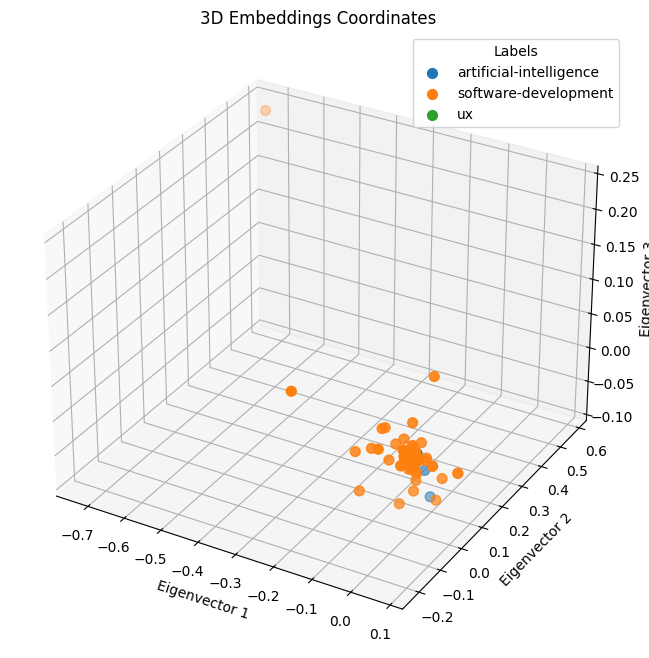

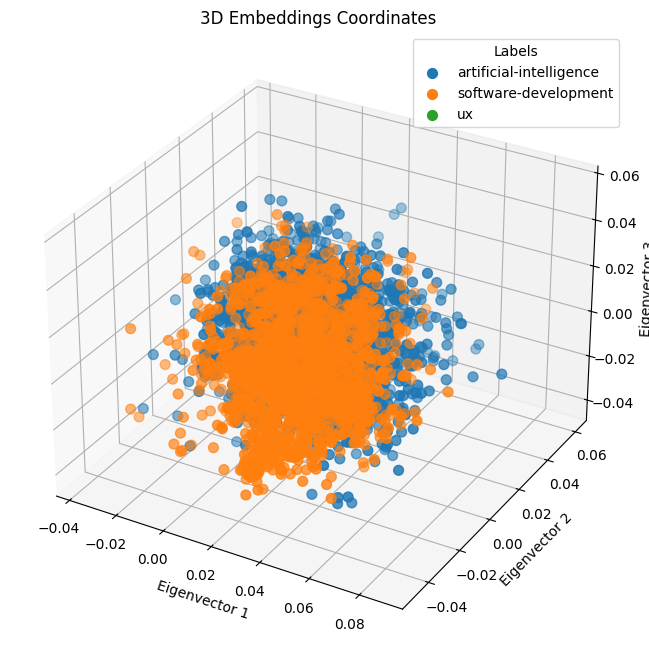

In [665]:
# Comparison between the best predictions found using Spectral Embeddings and Node Embeddings
print(f"Number of differently predicted nodes: {(np.array(predictions_test) != predictions_random_walks).sum()}")

plot_embeddings_3d(spectral_embeddings_test_data[:, :], predictions_test)
plot_embeddings_3d(test_embeddings[:, :], predictions_random_walks)